# Практическое использование Sympy

## Автор благодарит студентов факультетата математики и компьютерных наук КубГУ Щёлокова Дмитрия и Климантова Артёма за помощь в подготовке этой лекции

&nbsp;&nbsp;&nbsp;&nbsp; ***SymPy*** — это библиотека языка Python для выполнения символьных вычислений, то есть она работает с выражениями, содержащими символы.


&nbsp;&nbsp;&nbsp;&nbsp;В SymPy есть разные функции, которые применяются в сфере символьных вычислений, математического анализа, алгебры, дискретной математики и прочих областях математики.

&nbsp;&nbsp;&nbsp;&nbsp;SymPy может представлять результаты вычислений в разных форматах: LaTeX, MathML.

## Начало работы с Sympy

Для установовки библиотеки Sympy используем в консоли следующую команду: ***pip install Sympy***

Чтобы проверить наличие библиотеки и вывести её версию, достаточно ввести следующий код:

In [1]:
import sympy
sympy.__version__

'1.14.0'

Символьные вычисления — это разработка алгоритмов для управления математическими выражениями и другими объектами. Такие вычисления объединяют математику и компьютерные науки для решения математических выражений с помощью математических символов.

Система компьютерной алгебры, такая как SymPy, оценивает алгебраические выражения с помощью тех же символов, которые используются в традиционных ручных методах.

Например, **квадратный корень** числа с помощью модуля *math* в Python вычисляется вот так:

In [2]:
import math as mt

print(mt.sqrt(25), mt.sqrt(7))

5.0 2.6457513110645907


Как можно увидеть, квадратный корень числа 7 вычисляется приблизительно. Но в SymPy квадратные корни чисел, которые не являются идеальными квадратами, просто не вычисляются.

Используем функцию **init_printing()**, которая автоматически подключает функцию ***display()***, применяtve. для красивого вывода на экран различных формул, корней, интегралов и тд. 

In [3]:
import sympy
import math
sympy.init_printing() 
display(math.sqrt(7), sympy.sqrt(7))

Попробуем вычислить квадратный корень средствами библиотеки math и Sympy:

In [4]:
display(math.sqrt(12))
display(sympy.sqrt(12))

В случае с модулем *math* возвращается **число**, а вот в *SymPy* — **формула**.

## 1) Числа

Основной модуль в *SymPy* включает класс **Number**. У него есть пара подклассов: *Float* и *Rational*. В Rational также входит *Integer*.

***Класс Float***

**Float** представляет числа с плавающей точкой произвольной точности:

In [5]:
from sympy import Float 
from sympy import Rational
Float(6.32)

SymPy может также конвертировать *целое число* или *строку* в число с плавающей точкой.

In [6]:
display(Float(10), Float('1.234'))

При конвертации к числу с плавающей точкой, также можно указать *количество цифр* для точности:

In [7]:
Float('3.1415e5')

***Класс Rational***

Представить число дробью можно с помощью объекта класса **Rational**, где знаменатель — не 0:

In [8]:
Rational(3/4)

Если число с плавающей точкой передать в конструктор Rational(), то он вернет дробь:

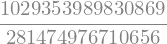

In [9]:
Rational(3.657)

Для упрощения можно указать ограничение знаменателя методом **limit_denominator**:

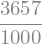

In [10]:
Rational(3.657).limit_denominator(10000)

Если же в конструктор передать строку, то вернется рациональное число произвольной точности:

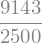

In [11]:
Rational('3.6572')

Также рациональное число можно получить, если в качестве аргументов передать два числа через запятую:

In [12]:
Rational(3, 5)

***Класс Integer***

Класс Integer в SymPy представляет целое число любого размера. Конструктор принимает рациональные и числа с плавающей точкой. В результате он отбрасываетт дробную часть:

In [13]:
from sympy import Integer

In [14]:
Integer(10), Integer(3.4), Integer(2/7)

В sympy также существуют одиночные классы чисел:

*Zero* - число 0

*One* - число 1

*Half* - 1/2

*NaN* - "не число", nan

*Infinity* (или символ *oo*) - бесконечность

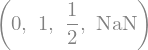

In [15]:
from sympy import S
S.Zero, S.One, S.Half, S.NaN

In [85]:
S.Zero

0

In [16]:
from sympy import oo
oo

## 2) Символы

Symbol — самый важный класс в библиотеке SymPy. Как уже упоминалось ранее, символьные вычисления выполняются с помощью символов. И переменные SymPy являются объектами класса Symbol.

Аргумент функции **Symbol()** — это *строка*, содержащая символ, который можно присвоить переменной.

In [17]:
from sympy import Symbol
x = Symbol('x') 
y = Symbol('y') 
expr = x**2 + y**2
expr

Один символ может включать больше одной буквы:

In [18]:
from sympy import Symbol
s = Symbol('side') 
s**3

Также в SymPy есть функция **symbols()**, с помощью которой можно определить несколько символов за раз. Строка содержит названия переменных, разделенные запятыми или пробелами:

In [19]:
from sympy import symbols
x, y, z = symbols("x, y, z")
display((x,y,z))

Библиотека *Sympy* содержит греческие буквы, которые можно использовать для записи переменных и формул:

In [20]:
alpha, beta, gamma, zeta, pi = symbols('alpha, beta, gamma, zeta, pi')
display((alpha, beta, gamma, zeta, pi))

### Подстановка параметров

Одна из базовых операций в математических выражениях — подстановка. Функция **subs()** заменяет все случаи первого параметра на второй:

In [21]:
x,a = symbols('x a')
expr = sympy.sin(x) * sympy.sin(x) + sympy.cos(x) * sympy.cos(x) 
expr

Чтобы заменить переменную $x$ на $a$ используем ***expr.subs(x,a)***:

In [22]:
expr.subs(x,a)

Эта функция полезна, когда требуется вычислить определенное выражение. Например, нужно посчитать значения выражения, заменив $a$ на $5$:

In [23]:
expr = a**2 + 2*a +5
expr

In [24]:
expr.subs(a,5)

Также эта функция используется для замены одного подвыражения другим. В следующем примере *b* заменяется на *a+b*:

In [25]:
a,b = symbols('a b')
expr = (a + b)**2
expr

In [26]:
expr1 = expr.subs(b,a+b)
expr1

В качестве параметров функции **subs()** можно передавать сразу несколько выражений, которые нужно заменить:

1. С помощью списка кортежей из двух элементов
2. С помощью словаря, состоящего из ключей (того, что нужно заменить) и полей (то, на что нужно заменить)

In [27]:
x, y, z = symbols('x y z')
exp = x**2 + 7 * y + z 
display(exp)   

In [28]:
res_exp1 = exp.subs([(x,2),(y,4),(z,1)])
res_exp2 = exp.subs({x:2, y:4, z:1})
display(res_exp1, res_exp2)

### Функция simplify()

Функция **simplify()** используется для преобразования любого произвольного выражения, чтобы его можно было использовать как выражение SymPy. Обычные объекты Python, такие как целые числа, конвертируются в SymPy.Integer и так далее. Строки также конвертируются в выражения SymPy:

In [29]:
expr = "x**2 + 3*x +  2" 
expr1 = sympy.sympify(expr)
display(expr1, expr1.subs(x,2))

### Функция evalf()

Функция **evalf()** вычисляет данное числовое выражение с точностью до 100 цифр после плавающей точки. Она также принимает параметр *subs* как объект словаря с числовыми значениями для символов. Например такое выражение даст результатом формулу площади круга:

In [30]:
from sympy import pi
r = Symbol('r')
expr2 = pi * r**2 
expr2

Вычислим выражение с помощью **evalf()** и заменим r на 5:

In [31]:
expr2.evalf(subs={r: 5})

По умолчанию функция выводит значения с точностью до 15 знаков, но это число можно увеличить вплоть до 100, если в *eval()* перед *subs* записать нужную точность:

In [32]:
a,b = symbols('a,b')
expr = a / b 
expr.evalf(20, subs={a: 100, b: 3})

### Функция Lambdify()

Функция **lambdify([x,y,..], expression)** переводит выражения SymPy в функции Python. Если выражение, которое нужно вычислить, затрагивает диапазон значений, то функция evalf() становится неэффективной.

Функция *lambdify* действует как лямбда-функция с тем исключением, что она конвертирует SymPy в имена данной числовой библиотеки, обычно *NumPy*. По умолчанию же она реализована на основе стандартной библиотеки *math*.

In [33]:
x = Symbol('x')
expr =1 / sympy.sin(x) 
f = sympy.lambdify([x], expr) 
f(3.14)

У выражения может быть больше одной переменной. В таком случае первым аргументом функции является список переменных, а после него — само выражение:

In [34]:
expr = a**2 + b**2 
f = sympy.lambdify([a, b], expr) 
f(2, 3)

Чтобы использовать *Numpy* в качестве основной библиотеки, ее нужно передать в качестве аргумента функции *lambdify()*:

In [36]:
f = sympy.lambdify([a, b], expr, "numpy")

## 4) Многочлены

In [37]:
import sympy
#Определяем два многочлена
x,y=sympy.symbols('x y')

Определяем два многочлена

In [38]:
eqq1 = 5*x**4 + 6*x + 3*x**2 - 36
eqq2 = 2*x + 8

In [39]:
eqq1

In [40]:
eqq2

Рассмотрим деление многочленов с остатком, параметр **domain** определяет какое множество используется для решения этой задачи (обозначения как в математике)

+ ZZ-целые
+ QQ-рациональные
+ RR-вещественные

In [41]:
quotient, remainder = sympy.div(eqq1, eqq2, domain="QQ")

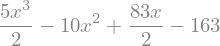

In [42]:
quotient

In [43]:
remainder

Сделаем проверку, для этого воспользуемся методом **.expand()**

In [44]:
(quotient*eqq2+remainder).expand()

#### НОД и НОК + проверка

In [45]:
f = 2*(x*y**2)
g = 37*(x**2*y)

In [46]:
f

In [47]:
g

Нахождение **НОД**

In [48]:
gcd_f_g=sympy.gcd(f,g)

gcd_f_g

Нахождение **НОK**

In [49]:
lcm_f_g=sympy.lcm(f,g)
lcm_f_g

Сделаем проверку. Произведение двух многочленов сравнимо с произведеним НОД и НОК этих же многочленов

In [50]:
(f*g).expand()

In [51]:
(gcd_f_g*lcm_f_g).expand()

### Разложение многочлена на множители

In [52]:
equ = 2*x**2 + 5*x**3 + 4*x**4 + x**5
equ

Для Бесквадратной факторизации многочлена на скобки есть два способа, отличающиеся видом выходных значений:

+ sqf()
+ sqf_list()

In [53]:
sympy.sqf(equ)

In [54]:
s_list=sympy.sqf_list(equ)
s_list

In [55]:
equ1 = (s_list[1][0][0]*(s_list[1][1][0]**s_list[1][1][1]))
equ1

In [56]:
equ1.expand()

Данный метод факторизации (разложения) предпологает получение не обязательно неупростимых множетелей. Для получения упрощенных множетелей есть функции:
1) **factor**
2) **factor_list**

In [57]:
sympy.factor(equ)

In [58]:
f_l = sympy.factor_list(equ)
f_l

In [59]:
equ1 = ((f_l[1][0][0]**f_l[1][0][1])*(f_l[1][1][0]**f_l[1][1][1])*(f_l[1][2][0]**f_l[1][2][1]))
equ1

In [60]:
equ1.expand()

## 5) Задачи математического анализа
### Вычисление пределов

Для нахождения предела так же как и для дифференцирования и интегрирования есть два возможных метода. Это найти предел сразу, используя функцию limit() или сначала создать неоценненный предел, используя Limit() и рассчитать отдельно через метод .doit()

Начнем с нескольких простейших пределов, например замечательный предел в общем виде

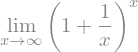

In [61]:
import sympy
x=sympy.symbols('x')
display(sympy.Limit((1+1/x)**x,x,sympy.oo))
sympy.limit((1+1/x)**x,x,sympy.oo)

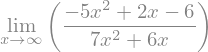

In [62]:
lim1 = sympy.Limit((-5*x**2+2*x-6)/(7*x**2+6*x), x, sympy.oo)
display(lim1)

In [63]:
lim1.doit()

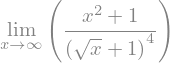

In [64]:
lim2 = sympy.Limit((x**2+1)/(sympy.root(x,2)+1)**4, x, sympy.oo)
display(lim2)

In [65]:
lim2.doit()

Пределы *справа* и *слева* можно вычислить с помощью параметра **dir**:
+ значение "+" (предел справа и по умолчанию),
+ значение "-" (предел слева).

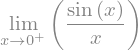

In [66]:
display(sympy.Limit(sympy.sin(x)/x, x, 0, dir="+"))
sympy.limit(sympy.sin(x)/x, x, 0, dir="+")

In [67]:
sympy.limit(sympy.sin(x)/x, x, 0)



### Дифференцирование

Дифференцировать математические выражения в форме переменных можно с помощью функции ***diff()*** из SymPy.

Пусть дано следующее выражение:

In [68]:
from sympy import diff, sin, exp
x,y = sympy.symbols('x,y')
expr = x*sin(x*x) + 1
expr

Чтобы найти первую производную по переменной *х* применим к выражению функцию **diff()**, либо метод **.diff()**:

In [69]:
d1 = diff(expr,x)
d2 = expr.diff(x)
display(d1, d2)

Если нужно найти производную высших порядков, после указания переменной нужно указать число - *количество раз дифференцирования*:

In [70]:
diff(expr,x,3)

Неоцененная производная создается с помощью функции ***Derivative()***. У него такой же синтаксис, как и функции *diff()*. Для оценки же достаточно использовать метод ***.doit()***.

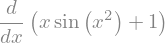

In [71]:
from sympy import Derivative
d = Derivative(expr)
d

In [72]:
d.doit()

### Разложение в ряд Тейлора
Разложение в ряд Тейлора осуществляется с помощью функции **series()**, использоване которой рассмотрим на примерах 

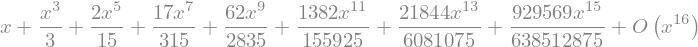

In [73]:
sympy.series(sympy.tan(x), x, 0, 16)

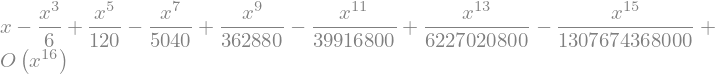

In [74]:
sympy.series(sympy.sin(x), x, 0, 16)

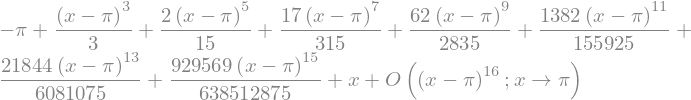

In [75]:
sympy.series(sympy.tan(x), x, sympy.pi, 16)

### Интегрирование

SymPy включает и модуль интегралов. В нем есть методы для вычисления определенных и неопределенных интегралов выражений. Метод ***integrate()*** используется для вычисления обоих интегралов.

Для вычисления *неопределенного* интеграла нужно просто передать переменную после выражения в функцию *integrate()*:

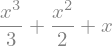

In [76]:
x,y = symbols('x,y')
expr = x**2 + x + 1
sympy.integrate(expr, x)

Пример вычисления *определённого* интеграла $\displaystyle \int\limits_{0}^{\infty} e^{- x^{2}}\, dx$:

In [77]:
expr1 = exp(-x**2)
sympy.integrate(expr1,(x,0,oo))

С помощью объекта ***Integral*** можно создать *неоцененный интеграл*. Он также оценивается с помощью метода *doit()*:

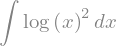

In [78]:
expr = sympy.Integral(sympy.log(x)**2,x)
expr

In [79]:
expr.doit()

## 6) Уравнения, неравенства и системы уравнений



### Простейшие уравнения, неравенства

Для начала рассмотрим решение простейших уравнений с один неизветстным, по умолчанию подразумевается, что правая чать уравнения ноль

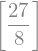

In [80]:
sympy.solve(8*x-27)

Но можно и не ноль

Поскольку символы = и == определены как символ присваивания и равенства в Python, их нельзя использовать для создания символьных уравнений. Для этого в SymPy есть функция **Eq()**.

In [81]:
x, y = sympy.symbols('x y') 
sympy.Eq(x, y)

Поскольку x=y возможно только в случае x-y=0, уравнение выше можно записать как:

In [82]:
sympy.Eq(x-y, 0)

Ещё один пример

In [83]:
res13=sympy.solve(sympy.Eq(3*x**2+4*x,3))

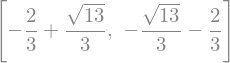

In [84]:
display(res13)

Для форматированного вывода можно использовать функцию **pprint()**

In [85]:
sympy.pprint(res13)

⎡  2   √13    √13   2⎤
⎢- ─ + ───, - ─── - ─⎥
⎣  3    3      3    3⎦


### Решение неравеств

In [86]:
from sympy import Symbol
from sympy.solvers.inequalities import reduce_rational_inequalities

In [87]:
x = Symbol('x', real=True)
reduce_rational_inequalities([[x**2 <= 3]], x)

In [88]:
sympy.pprint(reduce_rational_inequalities([[x**4 - 276 > 0]], x))

        4 ____      4 ____    
x < -√2⋅╲╱ 69  ∨ √2⋅╲╱ 69  < x


In [89]:
sympy.pprint(reduce_rational_inequalities([[x**3 - 27 >= 3]], x))

3 ____    
╲╱ 30  ≤ x


In [91]:
sympy.pprint(reduce_abs_inequality((sympy.Abs(x - 5) - 3), '>', x))

NameError: name 'reduce_abs_inequality' is not defined

In [92]:
sympy.pprint(reduce_abs_inequality((sympy.Abs(x - 5)), '<', x))

NameError: name 'reduce_abs_inequality' is not defined

In [93]:
sympy.pprint(reduce_abs_inequality((sympy.Abs(x - 5) - 3 - (sympy.Abs(59-x)+3)), '>', x))

NameError: name 'reduce_abs_inequality' is not defined

### Символьное решение квадратного уравнения

In [94]:
a,b,c=sympy.symbols('a b c')
kv=a*x**2+b*x+c
kv

In [95]:
reshenie_kv = sympy.solve(kv,x)
sympy.pprint(reshenie_kv)

⎡        _____________          _____________⎤
⎢       ╱           2          ╱           2 ⎥
⎢-b - ╲╱  -4⋅a⋅c + b    -b + ╲╱  -4⋅a⋅c + b  ⎥
⎢─────────────────────, ─────────────────────⎥
⎣         2⋅a                    2⋅a         ⎦


### Символьное решение кубического уравнения

In [96]:
a,b,c,d=sympy.symbols('a b c d')
kub=a*x**3+b*x**2+c*x+d
kub

In [97]:
reshenie_kub = sympy.solve(kub,x)
sympy.pprint(reshenie_kub)

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                 2                            ↪
⎢                                          3⋅c   b                             ↪
⎢                                        - ─── + ──                            ↪
⎢                                           a     2                            ↪
⎢                                                a                             ↪
⎢- ─────────────────────────────────────────────────────────────────────────── ↪
⎢               ____________

Модуль *solver* из SymPy предлагает функцию **solveset()** для решения простейших уравнений.

Например:
$\displaystyle x^{2} - 9 = 0$ или $\displaystyle x^{2} - 3 x = -2$

In [ ]:
sympy.solveset(sympy.Eq(x**2-9, 0), x)

In [ ]:
sympy.solveset(sympy.Eq(x**2-3*x, -2), x)

### Уравнения и системы

Для решения **линейных** уравнений или систем уравнений нужно использовать функцию **linsolve()**.

Например, уравнения могут быть такими:

    x-y=4
    x+y=1

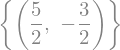

In [98]:
x,y = symbols('x,y')
sympy.linsolve([sympy.Eq(x-y,4),sympy.Eq(x+y,1)], (x,y))

Функция linsolve() также может решать линейные уравнения в матричной форме:

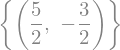

In [99]:
a, b = symbols('a, b') 
a = sympy.Matrix([[1, -1], [1, 1]]) 
b = sympy.Matrix([4, 1]) 
sympy.linsolve([a, b], (x,y))

Если задано нелинейное уравнение или система, то необходимо использовать функцию **nonlinsolve()**:

In [100]:
a, b = symbols('a,b') 
sympy.nonlinsolve([a**2 + a, a - b], (a, b))

### Дифференциальные уравнения

Для начала работы с дифференциальными уравнениями в Sympy, необходимо создать функцию, зависящую от переменной, которую мы будем находить. Делается это с помощью функции **Function()**:

In [101]:
t = symbols('t')
x = sympy.Function('x')(t)
display(x)

Чтобы *найти производную* для дифференциального уравнения воспользуемся функцией ***diff()***. Какой порядок дифференцирования нам необходим - столько раз указываем в скобках переменную, по которой дифференцируем функцию:

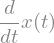

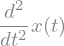

In [102]:
f1 = diff(x,t)
f2 = x.diff(t,t)
display(f1, f2)

Для решения дифференциальных уравнений используйте функция ***dsolve***.

Сначала создается объект *Eq*, соответствующий, например, следующему дифференциальному уравнению:
$$\frac{d}{d t} x{\left(t \right)} - \displaystyle x{\left(t \right)} = \sin{\left({t} \right)}$$

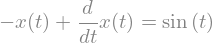

In [103]:
diff_eq = sympy.Eq(x.diff(t)-x,sin(t))
diff_eq

К полученному дифференциальному уравнению применяем функцию *dsolve*:

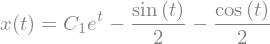

In [104]:
sympy.dsolve(diff_eq, x)

## Графики

SymPy использует библиотеку *matplotlib* в качестве библиотеки для рисования двухмерных и трехмерных графиков математических функций.

Функции для работы с графиками можно найти в модуле **sympy.plotting**:

    plot — двухмерные линейные графики.
    plot3d — трехмерные линейные графики.
    plot_parametric — двухмерные параметрические графики.
    plot3d_parametric — трехмерные параметрические графики.

Функция ***plot()*** возвращает экземпляр класса *Plot*. Сам график может включать одно или несколько выражений SymPy.

*plot(expr,range,kwargs)*

где expr — это любое подходящее выражение SymPy. Если не сказано другое, то по умолчанию значение диапазона *range* равно (-10, 10).

Следующий график показывает квадрат для каждого значения в диапазоне от -10 до 10:

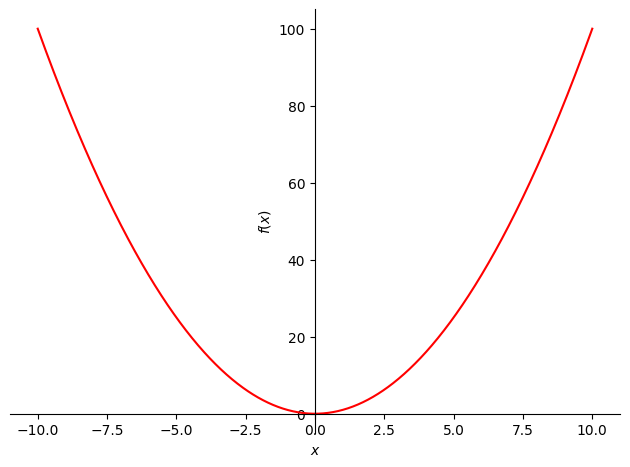

In [105]:
from sympy import * 
x = Symbol('x') 
sympy.plot(x**2, line_color='red')

Чтобы нарисовать несколько графиков для одного диапазона, перед кортежем нужно указать *несколько выражений*:

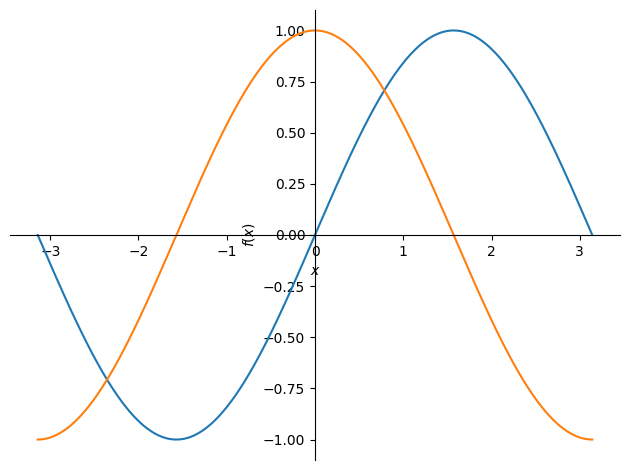

In [106]:
plot(sin(x), cos(x), (x, -pi, pi))

Также для каждого выражения можно задать отдельный диапазон:

*plot((expr1,range1),(expr2,range2))*

Например:

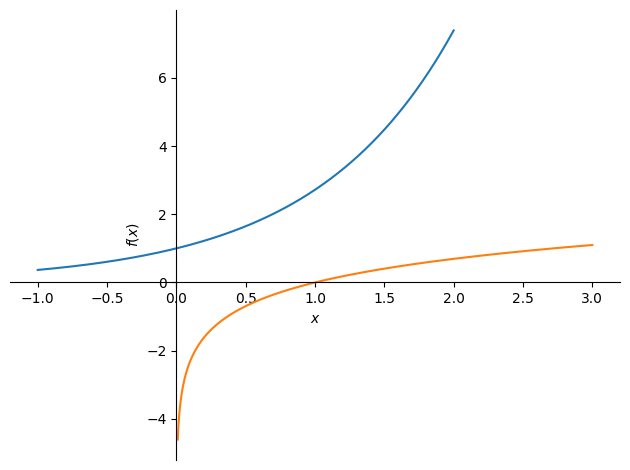

In [107]:
from sympy import * 
x = Symbol('x') 
plot((exp(x),(x,-1,2)),(log(x),(x,0.01,3)))

Также в функции *plot()* можно использовать следующие необязательные аргументы-ключевые слова.

    line_color — определяет цвет линии графика.
    title — название графика.
    xlabel — метка для оси X.
    ylabel — метка для оси Y.

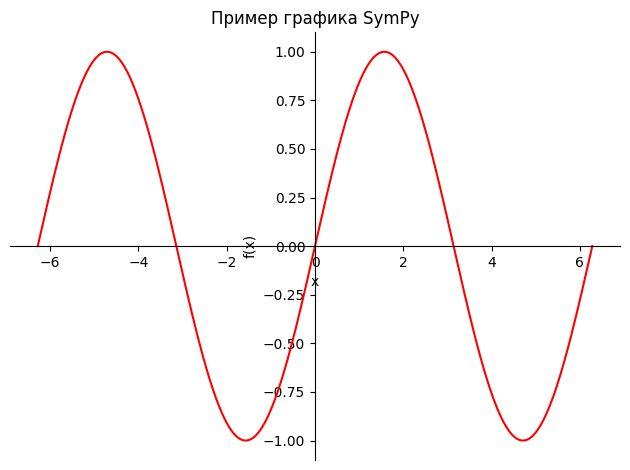

In [108]:
plot((sin(x), (x,-2*pi,2*pi)), line_color='red', title='Пример графика SymPy', xlabel='x', ylabel='f(x)')

Функция ***plot3d()*** рендерит трехмерный график:

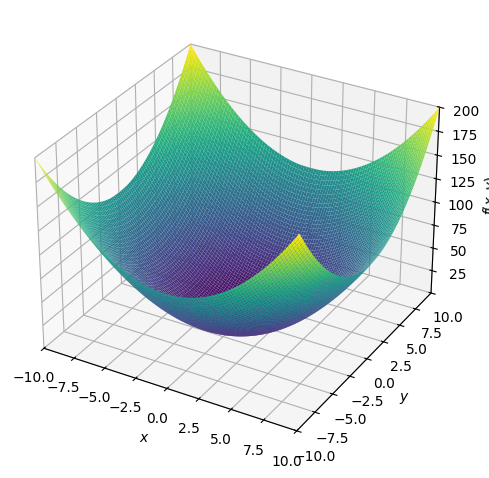

In [109]:
from sympy.plotting import plot3d 
x, y = symbols('x y') 
plot3d(x**2+y**2, (x, -10, 10), (y, -10, 10))

Функция ***plot3d_parametric_line()*** рендерит трехмерный линейный параметрический график:

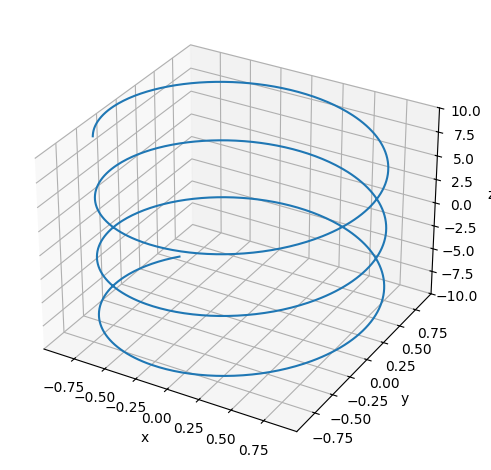

In [110]:
from sympy.plotting import plot3d_parametric_line 
plot3d_parametric_line(cos(x), sin(x), x, (x, -10, 10))

Помимо использования функции Plot() как части библиотеки Sympy, символьное выражение можно перевести в обычную функцию языка Python и использовать её для полноценной работы с библиотекой Matplotlib, что будет показано ниже.

# Совместное использование символьных и численных вычислений

&nbsp;&nbsp;&nbsp;&nbsp;В данном пункте продемонстрируем возможности совместного использования символьных вычисления Sympy и численных вычислений языка Python.

&nbsp;&nbsp;&nbsp;&nbsp;1) Аналитическое решение дифференциального уравнения 2-го порядка символьно и изображение графика решения

&nbsp;&nbsp;&nbsp;&nbsp;2) Символьное задание дифференциального уравнения 2-го порядка и его численное решение, сравнение численного решения с аналитическим

&nbsp;&nbsp;&nbsp;&nbsp;В рамках данного доклада рассмотрим решение уравнения колебаний.

&nbsp;&nbsp;&nbsp;&nbsp;Свободные колебания в реальных условиях не могут длиться вечно. Например, для механических систем всегда имеет место сопротивление среды, в результате чего энергия движения объекта рассеивается трением. В электромагнитных цепях колебания затухают из-за сопротивления проводников.

&nbsp;&nbsp;&nbsp;&nbsp;Поэтому мы будем решать именно ***уравнение затухающих колебаний*** для *пружинного маятника*

&nbsp;&nbsp;&nbsp;&nbsp;Уравнение затухающих колебаний описывает движение реальных колебательных систем. В дифференциальной форме он записывается следующим образом:

$$\displaystyle \frac{d^{2}}{d t^{2}} x{\left(t \right)} + 2 \beta \frac{d}{d t} x{\left(t \right)} + \omega_{0}^{2} x{\left(t \right)} = 0$$
$$\displaystyle x{\left(0 \right)} = a, \displaystyle \left. \frac{d}{d t} x{\left(t \right)} \right|_{\substack{ t=0 }} = b$$

где $x(t)$ - функция положения груза маятника в зависимости от времени $t$
<p>$a$ и $b$ - начальные условия для положения и скорости маятника

**I. Аналитическое решение**

&nbsp;&nbsp;&nbsp;&nbsp;Для начала подключим следующие библиотеки: Sympy (символьные вычисления), Numpy (работа с массивами), Matplotlib (для рисования графиков)

In [111]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

&nbsp;&nbsp;&nbsp;&nbsp;Зададим переменные для дифференциального уравнения с помощью фукнции **symbols**:
<p>t - аргумент функции
<p>r - коэффициент сопротивления среды
<p>k - коэффициент упругости прижины
<p>m - масса груза маятника
<p>C1 и C2 - константы решения дифференциального уравнения

In [112]:
t,C1,C2,r,k,m = symbols('t C1 C2 r k m')

&nbsp;&nbsp;&nbsp;&nbsp;Определим фукнцию $x(t)$ с помощью одноимённой фукнции **Function**, а также объявим переменные $\beta$ и $\omega_{0}$, которые являются коэффициентами при $x^{'}{\left(t \right)}$ и $x{\left(t \right)}$ соответственно

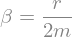

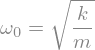

In [113]:
x = Function('x')(t)
beta, omega0 = symbols('beta omega0')
display(x, Eq(beta,r/(2*m)), Eq(omega0,sqrt(k/m)))

&nbsp;&nbsp;&nbsp;&nbsp;Зададим дифференциальное уравнение 2-го порядка, описывающее колебания маятника, и присвоим ему имя *diff_eq*, а также начальные условия $x(0)=5$, $ x^{'}{\left(0 \right)} = 0$

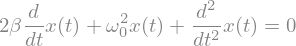

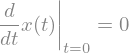

In [114]:
diff_eq = x.diff(t,t)+2*beta*x.diff(t)+omega0**2*x
ode = Eq(diff_eq,0)
x0 = 5
dx0 = 0
display(ode)
display(Eq(x.subs(t,0),x0),Eq(x.diff(t).subs(t,0),dx0))

&nbsp;&nbsp;&nbsp;&nbsp;Используем фукнцию **dsolve** для аналитического решения уравнения относительно фукнции $x(t)$:

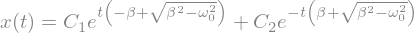

In [115]:
des = dsolve(ode,x)
display(des)

&nbsp;&nbsp;&nbsp;&nbsp;Необходимо найти коэффициенты $C_{0}$ и $C_{1}$, для этого необходимо решить *задачу Коши*

В правую часть решения *des.rhs* функцией *subs* подставляем начальное первое значение

In [116]:
eq1=des.rhs.subs(t,0)
display(Eq(x.subs(t,0),eq1))

Дифференцируем функцию $x(t)$ и подставляем второе начальное значение:

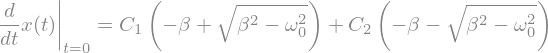

In [117]:
eq2=des.rhs.diff(t).subs(t,0)
display(Eq(x.diff(t).subs(t,0),eq2))

Функцией **Solve** решаем систему линейных уравнений $eq1$ и $eq2$ относительно пересенных $C_{1}$ и $C_{2}$:

\begin{equation*}
 \begin{cases}
   C_{1}+C_{2} = 5,\\
   C_{1} \left(- \beta - \sqrt{\beta^{2} - \omega_{0}^{2}}\right) + C_{2} \left(- \beta + \sqrt{\beta^{2} - \omega_{0}^{2}}\right) = 0.
 \end{cases}
\end{equation*}

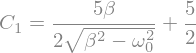

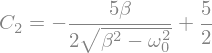

In [118]:
seq=solve([eq1-x0,eq2-dx0],C1,C2)
display(Eq(C1,seq[C1]))
display(Eq(C2,seq[C2]))

Подставляем найденные коэффициенты $C_{1}$ и $C_{2}$ в правую часть функцию $x(t)$:

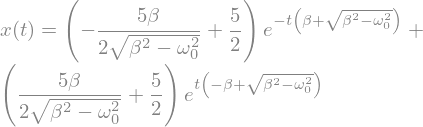

In [119]:
rez=des.rhs.subs([(C1,seq[C1]),(C2,seq[C2])])
display(Eq(x,rez))

Зададим коэффициенты $r, k, m$, определяющие свойства пружинного маятника, и подставим их в найденную фукнцию решения :

In [120]:
r, k, m = 0.8, 4, 2
rez = rez.subs({beta:(r/(2*m)), omega0:(sqrt(k/m))})

Функция **Lambdify** переводит символьную функцию в обычную функцию языка Python.

Функцией **plot** Библиотекой *Matplotlib* рисуем график колебаний пружинного маятника, получаем график затухающих колебаний с течением времени *от 0 секунд до 20 секунд*.

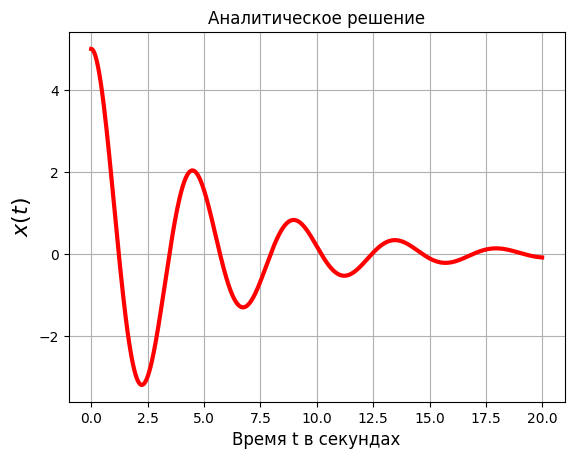

In [121]:
f=lambdify(t, rez, "numpy")

T = np.arange(0.0,20,0.01)
X = [f(i).real for i in T]
plt.plot(T,X,color='r', linewidth=3)
plt.xlabel('Время t в секундах',fontsize=12)
plt.ylabel('$x(t)$',fontsize=16)
plt.title('Аналитическое решение')
plt.grid()
plt.show()

**II. Численное решение**

Для численного решения нам понядобятся только следующие символы:
<p>t - аргумент функции
<p>r - коэффициент сопротивления среды
<p>k - коэффициент упругости прижины
<p>m - масса груза маятника
<p>Константы решений $C_{1}$ и $C_{2}$ нам не понадобятся

In [122]:
t,C1,C2,r,k,m = symbols('t C1 C2 r k m')

&nbsp;&nbsp;&nbsp;&nbsp;Снова определим фукнцию $x(t)$ с помощью фукнции **Function**, объявим переменные $\beta$ и $\omega_{0}$, которые являются коэффициентами при $\frac{d}{d t} x{\left(t \right)}$ и $x{\left(t \right)}$ соответственно:

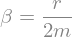

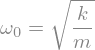

In [123]:
x = Function('x')(t)
beta, omega0 = symbols('beta omega0')
display(x, Eq(beta,r/(2*m)), Eq(omega0,sqrt(k/m)))

&nbsp;&nbsp;&nbsp;&nbsp;Зададим дифференциальное уравнение 2-го порядка, описывающее колебания маятника, и присвоим ему имя *diff_eq*

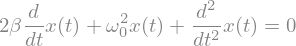

In [124]:
diff_eq = Eq(x.diff(t,t)+2*beta*x.diff(t)+omega0**2*x,0)
display(diff_eq)

&nbsp;&nbsp;&nbsp;&nbsp;Разрешим данное уравнение относительно второй производной функцией **Solve**:

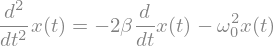

In [125]:
sol = solve(diff_eq,x.diff(t,t))[0]
eq = Eq(x.diff(t,t),sol)
display(eq)

&nbsp;&nbsp;&nbsp;&nbsp;Для численного решения дифференциального уравнения второго порядка необходимо свести её к системе дифференциальных уравнений *первого порядка*. Пусть $\displaystyle \frac{d}{d t} x{\left(t \right)} = y{\left(t \right)}$, тогда дифференциальное уравнение второго порядка можно свести к следующей системе с начальными условиями:
\begin{equation*}
 \begin{cases}
  \frac{d}{d t} x(t) = y(t) \\
  \frac{d}{d t} y(t) = - \frac{k x(t)}{m} - \frac{r y(t )}{m} \\
  x(0) = 5 \\
  y(0) = 0 \\
 \end{cases}
\end{equation*}

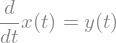

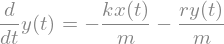

In [126]:
y = Function("y")(t)
display(Eq(x.diff(t),y))
func = eq.subs({x.diff(t):y,beta:r/(2*m),omega0:sqrt(k/m)})
display(func)

&nbsp;&nbsp;&nbsp;&nbsp;В правую часть уравнения $- \frac{k x{\left(t \right)}}{m} - \frac{r y{\left(t \right)}}{m}$ подставим коэффициенты $r, k, m$ и представим её как функцию языка Python функцией **Lambdify**, зависящую от двух переменных *x,y*:

In [127]:
f = lambdify([x,y],func.rhs.subs({r:0.8,k:4,m:2}))

Необходимо решить следующую систему дифференциальных уравнений:
\begin{equation*}
 \begin{cases}
\displaystyle \frac{d}{d t} x{\left(t \right)} = y{\left(t \right)}\\
\displaystyle \frac{d}{d t} y{\left(t \right)} = f{\left(x, y \right)}\\
\displaystyle x{\left(0 \right)} = {5}\\
\displaystyle y{\left(0 \right)} = {0}
 \end{cases}
\end{equation*}

Для решения следующей системы дифференциальных уравнений метод Рунге-Кутты 4 порядка:

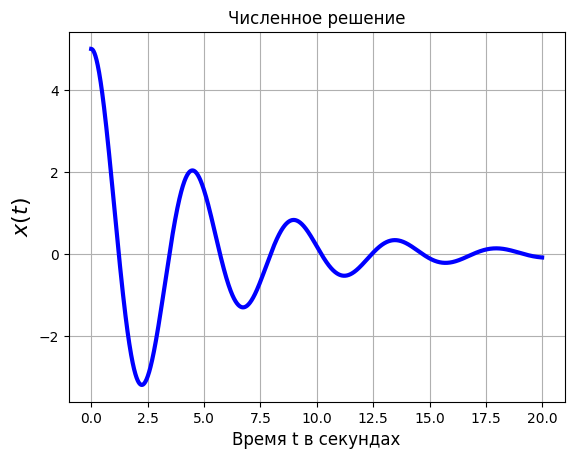

In [128]:
h = 0.01
n = int(20/h)
T,X_ch,Y = np.zeros(n), np.zeros(n), np.zeros(n)
X_ch[0] = 5
Y[0] = 0
for i in range(n-1):
    T[i+1] = (i+1)*h
    
    k1 = h*Y[i]
    l1 = h*f(X_ch[i],Y[i])
    
    k2 = h*(Y[i]+l1/2)
    l2 = h*f(X_ch[i]+k1/2,Y[i]+l1/2)
    
    k3 = h*(Y[i]+l2/2)
    l3 = h*f(X_ch[i]+k2/2,Y[i]+l2/2)
    
    k4 = h*(Y[i]+l3)
    l4 = h*f(X_ch[i]+k3,Y[i]+l3)
    
    X_ch[i+1] = X_ch[i] + (k1+2*k2+2*k3+k4)/6
    Y[i+1] = Y[i] + (l1+2*l2+2*l3+l4)/6

plt.plot(T,X_ch,color='b', linewidth=3)
plt.xlabel('Время t в секундах',fontsize=12)
plt.ylabel('$x(t)$',fontsize=16)
plt.title('Численное решение')
plt.grid(True)
plt.show()

Для сравнения, объединим на одном графике аналитическое и численное решение дифференциального уравнения:

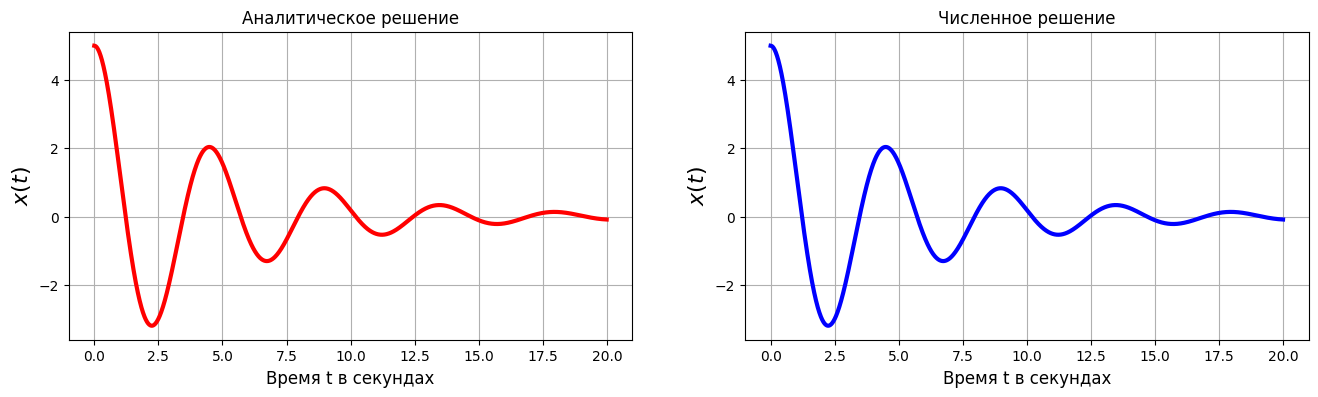

In [129]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(T,X,color='r', linewidth=3)

axs[1].plot(T,X_ch,color='b', linewidth=3)


axs[0].set_xlabel('Время t в секундах',fontsize=12)
axs[0].set_ylabel('$x(t)$',fontsize=16)
axs[0].set_title('Аналитическое решение')
axs[1].set_xlabel('Время t в секундах',fontsize=12)
axs[1].set_ylabel('$x(t)$',fontsize=16)
axs[1].set_title('Численное решение')

axs[0].grid(True)
axs[1].grid(True)
plt.show()

In [ ]:
Ресурсы и  книги для дальнейшего знакомства с sympy

1. Доля П.Г. Введение в научный Python в двух частях. Харьков, 2016.
2. https://docs.sympy.org/latest/index.html